# SIH26174 — Notebook 03: Object Detection Testing (Pretrained YOLOv8)

**Project:** BAS Experiment Monitor (SIH26174) — AI Human Activity Recognition for On-board BAS Experiments
**Part:** Part 1 — Model Development (Training Pipeline)
**Stage:** Notebook 03 of the training pipeline

## 1. Objective and Architecture Boundary

This notebook tests whether **pretrained** Ultralytics YOLOv8 is good enough as the object-detection
supporting component for the SIH26174 internal-round prototype. It is a **diagnostic/testing**
notebook, not a training notebook.

It answers:

1. Does YOLOv8 load correctly?
2. Does pretrained inference run correctly?
3. Which standard (COCO) object classes does it detect in representative HMDB51 frames?
4. What do detection confidence and bounding boxes look like?
5. Are the detections visually reasonable?
6. Is pretrained YOLOv8 practically usable as-is?
7. What are its limitations for this project?

### What this notebook does NOT do

- It does **not** train or fine-tune YOLOv8.
- It does **not** create bounding-box annotations from HMDB51.
- It does **not** fabricate object labels from HMDB51 class names.
- It does **not** run action recognition or train any action-recognition model.
- It does **not** implement experiment validation, state-machine logic, GUI, or voice alerts
  (Part 2 concerns).
- It does **not** run inference over the full HMDB51 dataset — only a small, deterministic sample.

### Architectural boundary (important — two separate label spaces)

```text
Video
  |
  v
YOLOv8 (pretrained, COCO classes)
  |
  v
Object detections   <-- THIS NOTEBOOK

Video
  |
  v
Action Recognition Model (trained on HMDB51, in a later notebook)
  |
  v
Action + confidence

Action + Experiment State
  |
  v
State Machine (Part 2)
  |
  v
VALID / INVALID
```

**HMDB51 action labels** (e.g. `drink`, `catch`, `sword`) and **YOLOv8's pretrained COCO object
labels** (e.g. `person`, `bottle`, `sports ball`) are **different label spaces**. A YOLO detection
in a frame does **not** mean the corresponding HMDB51 action was recognized — those are unrelated
claims. This notebook only reports what objects YOLOv8 sees, nothing about actions.


## 2. Imports

In [ ]:
import os
import sys
import json
import time
import random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("OpenCV version:", cv2.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)


Python version: 3.13.15
OpenCV version: 4.14.0
Pandas version: 2.2.3
NumPy version: 2.1.3


### 2.1 Install / Import Ultralytics

Ultralytics is installed if it is not already available. This also brings in PyTorch as a
dependency, which is used below to check for CUDA/GPU availability.


In [ ]:
# 2.1 INSTALL / IMPORT ULTRALYTICS

try:
    from ultralytics import YOLO
    import ultralytics
    print("Ultralytics available:", ultralytics.__version__)
except ImportError:
    print("Ultralytics not found — installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
    from ultralytics import YOLO
    import ultralytics
    print("Ultralytics installed:", ultralytics.__version__)

import torch
print("PyTorch version:", torch.__version__)


Ultralytics not found — installing...
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics installed: 8.4.139
PyTorch version: 2.11.0+cpu


## 3. Configuration

Every path, model choice, sampling parameter, and threshold used in this notebook is defined here
— nowhere else. `DATASET_ROOT` is the only hardcoded absolute path, consistent with Notebooks 01
and 02.


In [ ]:
# ---------------------------------------------------------------------------
# Authoritative project paths
# ---------------------------------------------------------------------------
TRAINING_ROOT = Path("/content/drive/MyDrive/SIH26174/training")
DATASET_ROOT = TRAINING_ROOT / "data/raw/hmdb51_sta"
REPORTS_DIR = TRAINING_ROOT / "reports"
CHECKPOINTS_DIR = TRAINING_ROOT / "checkpoints/yolo"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

DETECTION_REPORT_JSON_PATH = REPORTS_DIR / "yolo_object_detection_test.json"
DETECTION_REPORT_MD_PATH = REPORTS_DIR / "yolo_object_detection_test.md"
VISUALIZATION_PATH = REPORTS_DIR / "yolo_object_detection_examples.png"

SUPPORTED_VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv", ".webm"}

# ---------------------------------------------------------------------------
# YOLO baseline configuration
# ---------------------------------------------------------------------------
YOLO_WEIGHTS = "yolov8n.pt"
YOLO_CONFIDENCE = 0.25
MODEL_WEIGHTS = YOLO_WEIGHTS  # backward-compatible alias for existing cells
CONFIDENCE_THRESHOLD = YOLO_CONFIDENCE

# ---------------------------------------------------------------------------
# Deterministic sampling
# ---------------------------------------------------------------------------
RANDOM_SEED = 42
VIDEOS_PER_CLASS = 2
NUM_VIDEOS_PER_CLASS = VIDEOS_PER_CLASS  # backward-compatible alias
FRAMES_PER_VIDEO = 3  # start, middle, end-ish

PREFERRED_SAMPLE_CLASSES = [
    "catch", "throw", "drink", "eat", "clap", "kick_ball", "sword"
]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("TRAINING_ROOT   :", TRAINING_ROOT)
print("DATASET_ROOT    :", DATASET_ROOT)
print("REPORTS_DIR     :", REPORTS_DIR)
print("CHECKPOINTS_DIR :", CHECKPOINTS_DIR)
print("YOLO_WEIGHTS    :", YOLO_WEIGHTS)
print("YOLO_CONFIDENCE :", YOLO_CONFIDENCE)
print(f"Sampling {VIDEOS_PER_CLASS} video(s)/class and {FRAMES_PER_VIDEO} representative frames/video")


TRAINING_ROOT   : /content/drive/MyDrive/SIH26174/training
DATASET_ROOT    : /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
REPORTS_DIR     : /content/drive/MyDrive/SIH26174/training/reports
CHECKPOINTS_DIR : /content/drive/MyDrive/SIH26174/training/checkpoints/yolo
YOLO_WEIGHTS    : yolov8n.pt
YOLO_CONFIDENCE : 0.25
Sampling 2 video(s)/class and 3 representative frames/video


## 4. Mount Google Drive

Mounts Drive when running in Colab; falls back gracefully outside Colab as long as `DATASET_ROOT`
is reachable another way.


In [ ]:
from pathlib import Path
import shutil

MOUNT_POINT = Path("/content/drive")

if IN_COLAB:
    from google.colab import drive

    if MOUNT_POINT.exists():
        try:
            if MOUNT_POINT.is_symlink():
                MOUNT_POINT.unlink()
            elif MOUNT_POINT.is_dir() and any(MOUNT_POINT.iterdir()):
                print(f"Removing existing mount contents: {MOUNT_POINT}")
                shutil.rmtree(MOUNT_POINT)
        except Exception as e:
            print(f"Could not clean mount point: {e}")

    MOUNT_POINT.mkdir(parents=True, exist_ok=True)
    drive.mount(str(MOUNT_POINT), force_remount=True)

print("Drive mount complete.")






Removing existing mount contents: /content/drive
Mounted at /content/drive
Drive mount complete.


## 5. Verify Dataset Path

Confirm the HMDB51 dataset root exists before selecting any sample videos. This dataset is treated
strictly as read-only source material — nothing here is renamed, moved, or modified.


In [ ]:
if not DATASET_ROOT.exists() or not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        "Authoritative HMDB51 dataset root was not found.\n"
        f"Expected: {DATASET_ROOT}\n"
        "Mount Google Drive and verify that hmdb51_sta was extracted under "
        "/content/drive/MyDrive/SIH26174/training/data/raw/."
    )

print("Dataset root OK:", DATASET_ROOT)


Dataset root OK: /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta


## 6. Load Pretrained YOLOv8

Load the pretrained model, print its name, and confirm it loaded successfully. No training or
fine-tuning happens here or anywhere else in this notebook.


In [ ]:
model_load_start = time.time()
model = YOLO(YOLO_WEIGHTS)
model_load_seconds = time.time() - model_load_start

print(f"Loaded model weights : {YOLO_WEIGHTS}")
print(f"Model task            : {model.task}")
print(f"Number of COCO classes: {len(model.names)}")
print(f"Model load time        : {model_load_seconds:.2f}s")
print("Model loaded successfully.")


Loaded model weights : yolov8n.pt
Model task            : detect
Number of COCO classes: 80
Model load time        : 0.55s
Model loaded successfully.


## 7. Verify Inference Device

Use CUDA if available, otherwise CPU. The notebook must not fail merely because a GPU is
unavailable — Colab CPU-only runtimes are a valid (if slower) environment for this test.


In [ ]:
cuda_available = torch.cuda.is_available()
DEVICE = 0 if cuda_available else "cpu"

print("CUDA available:", cuda_available)
print("Inference device:", DEVICE)
if cuda_available:
    print("GPU name       :", torch.cuda.get_device_name(0))
else:
    print("GPU name       : CPU fallback")


CUDA available: False
Inference device: cpu
GPU name       : CPU fallback


## 8. Select Representative HMDB51 Videos

Deterministically select a small set of HMDB51 videos to test against. We start from
`PREFERRED_SAMPLE_CLASSES` — action classes more likely to contain COCO-recognizable objects — but
only keep the ones that actually exist in this dataset copy, and top up with other randomly chosen
(but seeded) classes if needed to reach `NUM_CLASSES_TO_SAMPLE`.

This selection is for **testing convenience only**. It does not imply that HMDB51 class names are
YOLO object classes, and it does not guarantee every selected class will contain a detectable
object.


In [ ]:
def discover_class_dirs(dataset_root: Path):
    return sorted(
        p.name for p in dataset_root.iterdir()
        if p.is_dir() and not p.name.startswith(".")
    )


def find_video_files(class_dir: Path):
    if not class_dir.is_dir():
        return []
    return sorted(
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in SUPPORTED_VIDEO_EXTENSIONS
    )


all_class_names = discover_class_dirs(DATASET_ROOT)
print(f"Total HMDB51 classes found on disk: {len(all_class_names)}")

rng = random.Random(RANDOM_SEED)
available_preferred = [c for c in PREFERRED_SAMPLE_CLASSES if c in all_class_names]
missing_preferred = [c for c in PREFERRED_SAMPLE_CLASSES if c not in all_class_names]

if missing_preferred:
    print("Preferred classes missing and skipped:", missing_preferred)

selected_classes = available_preferred.copy()
print(f"Selected preferred classes present on disk: {len(selected_classes)}")
print(" ", selected_classes)


Total HMDB51 classes found on disk: 51
Selected preferred classes present on disk: 7
  ['catch', 'throw', 'drink', 'eat', 'clap', 'kick_ball', 'sword']


In [ ]:
sample_video_records = []
missing_video_classes = []

for class_name in selected_classes:
    class_dir = DATASET_ROOT / class_name
    videos = find_video_files(class_dir)
    if not videos:
        missing_video_classes.append(class_name)
        print(f"WARNING: no video files found for class '{class_name}' — skipping.")
        continue

    chosen = rng.sample(videos, min(VIDEOS_PER_CLASS, len(videos)))
    for video_path in chosen:
        sample_video_records.append({
            "video_path": video_path,
            "class_name": class_name,
        })

print(f"Total sample videos selected: {len(sample_video_records)}")
for rec in sample_video_records:
    print(f"  [{rec['class_name']}] {rec['video_path'].name}")


Total sample videos selected: 14
  [catch] Torwarttraining_catch_f_cm_np1_le_bad_3.avi
  [catch] Florian_Fromlowitz_beim_Training_der_U_21_Nationalmannschaft_catch_u_cm_np1_le_med_1.avi
  [throw] 2008-08-09GiantsGameDodgersPracticeClaytonKershaw_throw_f_cm_np1_fr_med_2.avi
  [throw] amazingballthrowingtricks_throw_f_cm_np1_ri_med_1.avi
  [drink] Hitch_Part_1_drink_h_nm_np1_le_goo_5.avi
  [drink] Finding_Forrester_4_drink_h_cm_np1_ri_med_4.avi
  [eat] CharlieAndTheChocolateFactory_eat_u_nm_np1_fr_goo_22.avi
  [eat] CastAway1_eat_h_nm_np1_fr_goo_8.avi
  [clap] Clap_Hands_clap_u_nm_np1_fr_med_1.avi
  [clap] Budam_-_Clap_Hands_clap_u_nm_np1_fr_med_0.avi
  [kick_ball] The_Monk_Best_Bits_2_kick_ball_f_cm_np5_le_goo_1.avi
  [kick_ball] BRIAN_CLOUGH_-_ON_THE_TRAINING_GROUND_kick_ball_f_cm_np1_ri_med_0.avi
  [sword] AHF_longsword_against_Rapier_and_Dagger_Fight_sword_f_cm_np2_ri_bad_0.avi
  [sword] Baddest_Fight_Scenes_EVER!_-_Kill_Bill__Vol___1_-_vs__Crazy_88_s_sword_u_cm_np6_ri_med_0.avi


## 9. Extract Representative Frames

For each selected video, extract a small number of evenly spaced frames (`FRAMES_PER_VIDEO`)
rather than scanning the whole video. Unreadable videos are reported and skipped, not treated as a
fatal error.


In [ ]:
def extract_representative_frames(video_path: Path, num_frames: int):
    """Extract start, middle, and end-ish frames safely."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return []

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    if not np.isfinite(fps) or fps < 0:
        fps = 0.0

    if frame_count <= 0:
        cap.release()
        return []

    if num_frames == 1:
        positions = [(frame_count // 2, "middle")]
    elif num_frames == 2:
        positions = [(0, "start"), (max(frame_count - 1, 0), "end") ]
    else:
        positions = [
            (0, "start"),
            (frame_count // 2, "middle"),
            (max(frame_count - 2, 0), "end-ish"),
        ]

    frames = []
    for idx, position_label in positions:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        read_success = bool(ok and frame is not None and frame.size > 0)

        record = {
            "frame_index": int(idx),
            "frame_position_label": position_label,
            "frame": frame if read_success else None,
            "frame_width": int(frame.shape[1]) if read_success else 0,
            "frame_height": int(frame.shape[0]) if read_success else 0,
            "fps": float(fps),
            "read_success": read_success,
        }
        frames.append(record)

    cap.release()
    return frames


test_frames = []
sampled_frame_metadata = []
unreadable_sample_videos = []

for rec in sample_video_records:
    frames = extract_representative_frames(rec["video_path"], FRAMES_PER_VIDEO)
    if not frames:
        unreadable_sample_videos.append(str(rec["video_path"]))
        continue

    for item in frames:
        metadata = {
            "hmdb51_action_class": rec["class_name"],
            "video_path": str(rec["video_path"]),
            "frame_idx": int(item["frame_index"]),
            "frame_position_label": item["frame_position_label"],
            "frame_width": int(item["frame_width"]),
            "frame_height": int(item["frame_height"]),
            "fps": float(item["fps"]),
            "read_success": bool(item["read_success"]),
        }
        sampled_frame_metadata.append(metadata)

        if item["read_success"]:
            test_frames.append({
                "video_path": rec["video_path"],
                "class_name": rec["class_name"],
                "frame_index": item["frame_index"],
                "frame_position_label": item["frame_position_label"],
                "frame": item["frame"],
                "frame_width": item["frame_width"],
                "frame_height": item["frame_height"],
                "fps": item["fps"],
            })

print(f"Representative frame records: {len(sampled_frame_metadata)}")
print(f"Readable sampled frames    : {len(test_frames)}")
if unreadable_sample_videos:
    print(f"WARNING: {len(unreadable_sample_videos)} sample video(s) could not be opened/read:")
    for v in unreadable_sample_videos:
        print("  -", v)


Representative frame records: 42
Readable sampled frames    : 42


## 10. Run YOLOv8 Inference

Run pretrained YOLOv8 inference on each extracted frame. For every detection above
`YOLO_CONFIDENCE` we record the source video, the HMDB51 action-class label, the detected
YOLO object class, its confidence, and its bounding box — explicitly keeping these two label
spaces (action vs. object) as separate columns.


In [ ]:
detection_records = []
per_frame_results = []
per_frame_timings = []

for item in test_frames:
    frame_bgr = item["frame"]
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    start = time.time()
    results = model.predict(
        source=frame_rgb,
        conf=YOLO_CONFIDENCE,
        device=DEVICE,
        verbose=False,
    )
    elapsed = time.time() - start
    per_frame_timings.append(elapsed)

    result = results[0]
    per_frame_results.append({
        "video_path": item["video_path"],
        "class_name": item["class_name"],
        "frame_index": item["frame_index"],
        "frame_position_label": item["frame_position_label"],
        "result": result,
        "frame_rgb": frame_rgb,
    })

    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        continue

    image_height, image_width = frame_rgb.shape[:2]
    image_area = float(image_width * image_height)

    for box in boxes:
        cls_id = int(box.cls[0])
        confidence = float(box.conf[0])
        x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].tolist()]
        bbox_area = max(0.0, x2 - x1) * max(0.0, y2 - y1)

        detection_records.append({
            "hmdb51_action_class": item["class_name"],
            "video_path": str(item["video_path"]),
            "frame_idx": int(item["frame_index"]),
            "frame_position_label": item["frame_position_label"],
            "yolo_class_id": cls_id,
            "yolo_class_name": str(model.names[cls_id]),
            "confidence": round(confidence, 4),
            "bbox_xyxy": [round(x1, 1), round(y1, 1), round(x2, 1), round(y2, 1)],
            "bbox_area": round(bbox_area, 2),
            "image_width": int(image_width),
            "image_height": int(image_height),
            "normalized_bbox_area": round(bbox_area / image_area, 6) if image_area > 0 else 0.0,
        })

detections_df = pd.DataFrame(detection_records)

frames_with_detection = len({
    (d["video_path"], d["frame_idx"]) for d in detection_records
})

print(f"Frames sampled/read     : {len(test_frames)}")
print(f"Total detections        : {len(detections_df)}")
print(f"Frames with >=1 detection: {frames_with_detection} / {len(test_frames)}")

detections_df.head(10)


Frames sampled/read     : 42
Total detections        : 124
Frames with >=1 detection: 37 / 42


,hmdb51_action_class,video_path,frame_idx,frame_position_label,yolo_class_id,yolo_class_name,confidence,bbox_xyxy,bbox_area,image_width,image_height,normalized_bbox_area
0,catch,/content/drive/MyDrive/SIH26174/training/data/...,0,start,0,person,0.9074,"[214.4, 41.4, 282.2, 232.6]",12959.51,328,236,0.167418
1,catch,/content/drive/MyDrive/SIH26174/training/data/...,17,middle,0,person,0.8005,"[212.4, 64.4, 261.4, 233.4]",8293.18,328,236,0.107136
2,catch,/content/drive/MyDrive/SIH26174/training/data/...,32,end-ish,0,person,0.8786,"[191.7, 62.3, 262.6, 233.2]",12116.38,328,236,0.156526
3,catch,/content/drive/MyDrive/SIH26174/training/data/...,0,start,0,person,0.8781,"[113.8, 77.8, 157.5, 194.1]",5078.96,416,240,0.050871
4,catch,/content/drive/MyDrive/SIH26174/training/data/...,0,start,32,sports ball,0.7938,"[69.5, 179.4, 84.8, 192.9]",207.15,416,240,0.002075
5,catch,/content/drive/MyDrive/SIH26174/training/data/...,0,start,0,person,0.6047,"[238.3, 138.4, 285.4, 195.5]",2689.75,416,240,0.026941
6,catch,/content/drive/MyDrive/SIH26174/training/data/...,0,start,38,tennis racket,0.4335,"[230.0, 154.6, 257.4, 165.1]",287.51,416,240,0.002880
7,catch,/content/drive/MyDrive/SIH26174/training/data/...,17,middle,0,person,0.9017,"[208.9, 118.0, 272.5, 192.9]",4768.89,416,240,0.047765
8,catch,/content/drive/MyDrive/SIH26174/training/data/...,17,middle,32,sports ball,0.8390,"[69.7, 180.0, 84.7, 193.5]",203.01,416,240,0.002033
9,catch,/content/drive/MyDrive/SIH26174/training/data/...,17,middle,0,person,0.8197,"[110.6, 79.8, 168.8, 194.7]",6683.21,416,240,0.066939


## 11. Visualize Detections

Show annotated frames (bounding boxes + YOLO class + confidence) for a small subset of the tested
frames, so the detections can be judged visually. Each figure caption also shows the HMDB51 action
label for context — this is display convenience only, not a claim that the two labels are related.


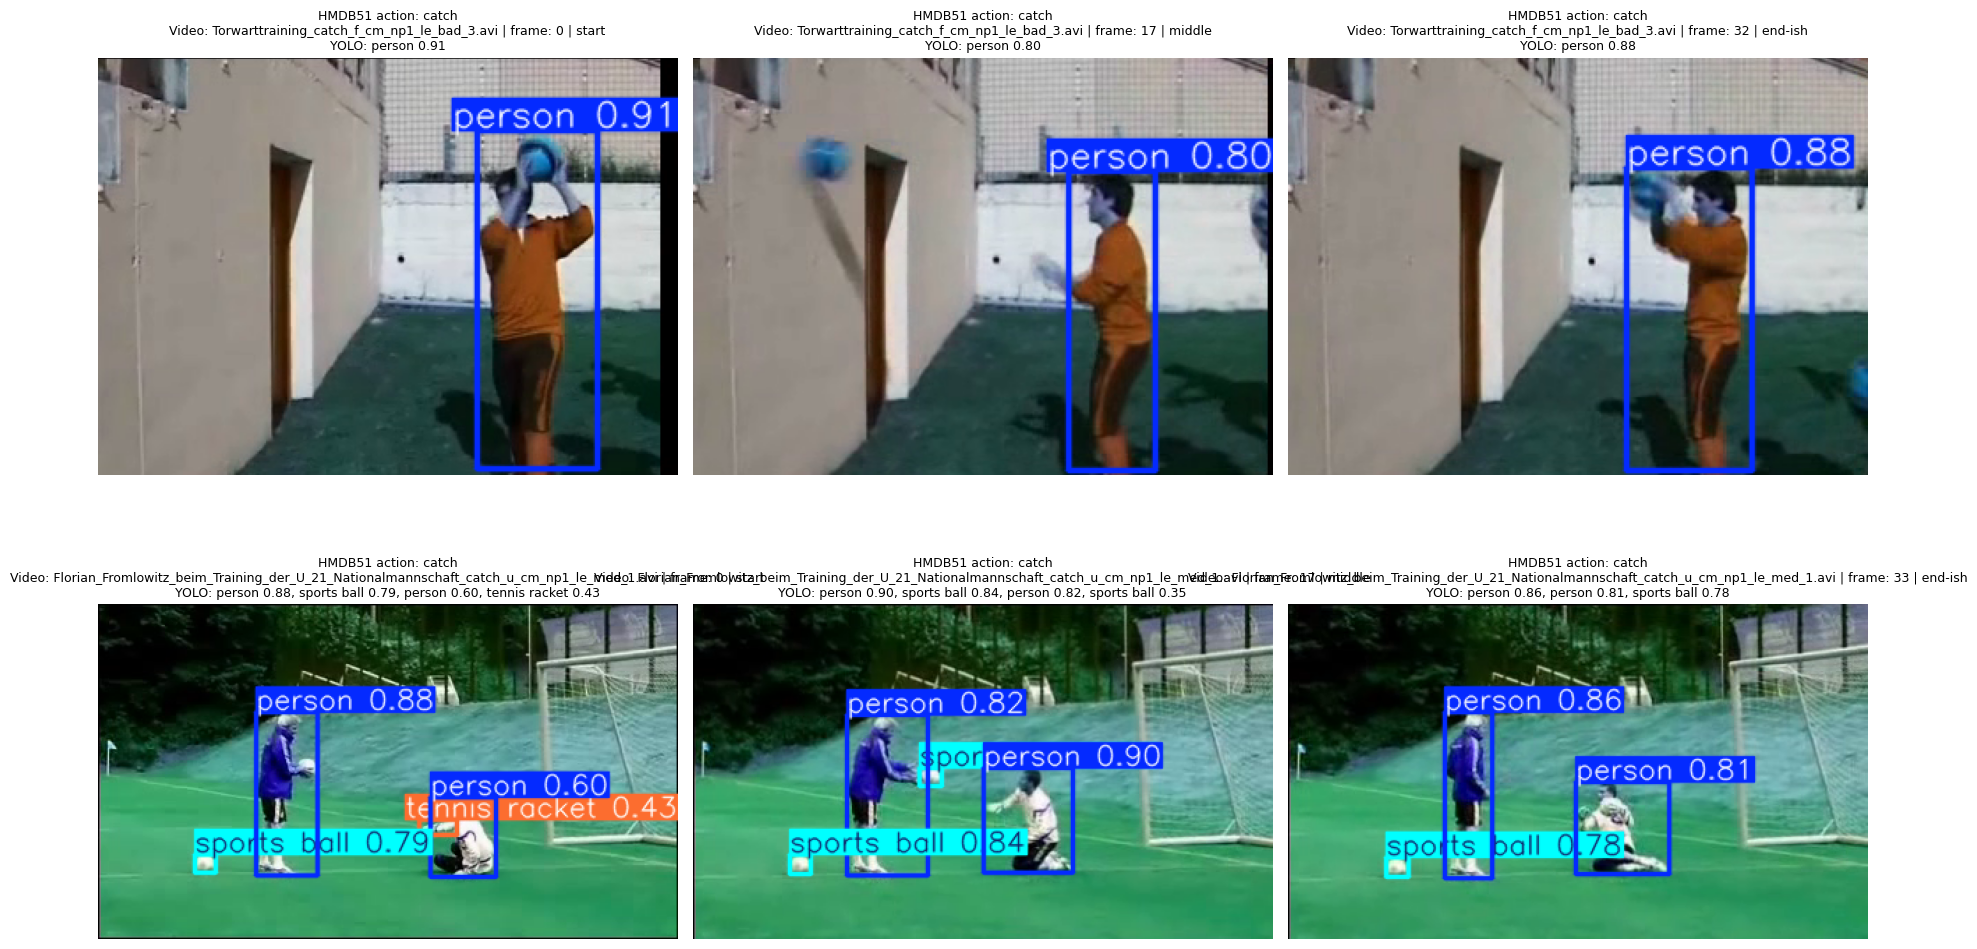

Saved visualization -> /content/drive/MyDrive/SIH26174/training/reports/yolo_object_detection_examples.png


In [ ]:
MAX_VISUALIZED_FRAMES = 6
frames_to_show = per_frame_results[:MAX_VISUALIZED_FRAMES]
num_show = len(frames_to_show)

if num_show == 0:
    print("No readable frames available to visualize.")
else:
    cols = min(3, num_show)
    rows = (num_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5.5 * rows))
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, item in zip(axes, frames_to_show):
        annotated_bgr = item["result"].plot()
        annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

        labels = []
        boxes = item["result"].boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                labels.append(f"{model.names[cls_id]} {conf:.2f}")

        detection_text = ", ".join(labels) if labels else "No YOLO detections"
        video_name = Path(item["video_path"]).name

        ax.imshow(annotated_rgb)
        ax.set_title(
            f"HMDB51 action: {item['class_name']}\n"
            f"Video: {video_name} | frame: {item['frame_index']} | {item['frame_position_label']}\n"
            f"YOLO: {detection_text}",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[num_show:]:
        ax.axis("off")

    plt.tight_layout()
    fig.savefig(VISUALIZATION_PATH, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved visualization ->", VISUALIZATION_PATH)


## 12. Summarize Detected Objects

Aggregate which YOLO object classes appeared in the sample, and how often, across all tested
frames.


In [ ]:
if not detections_df.empty:
    object_class_counts = (
        detections_df["yolo_class_name"]
        .value_counts()
        .rename_axis("yolo_class_name")
        .reset_index(name="detection_count")
    )
    detected_object_classes = sorted(
        detections_df["yolo_class_name"].unique().tolist()
    )
else:
    object_class_counts = pd.DataFrame(
        columns=["yolo_class_name", "detection_count"]
    )
    detected_object_classes = []

num_sampled_frames = len(test_frames)
num_frames_with_detection = frames_with_detection
detection_rate = (
    num_frames_with_detection / num_sampled_frames
    if num_sampled_frames else 0.0
)
avg_detections_per_frame = (
    len(detection_records) / num_sampled_frames
    if num_sampled_frames else 0.0
)
avg_detection_confidence = (
    float(detections_df["confidence"].mean())
    if not detections_df.empty else 0.0
)

frame_keys = {(r["video_path"], r["frame_idx"]) for r in detection_records}
person_frames = sum(
    1 for key in frame_keys
    if any(
        r["video_path"] == key[0] and r["frame_idx"] == key[1]
        and r["yolo_class_name"] == "person"
        for r in detection_records
    )
)
sports_ball_frames = sum(
    1 for key in frame_keys
    if any(
        r["video_path"] == key[0] and r["frame_idx"] == key[1]
        and r["yolo_class_name"] == "sports ball"
        for r in detection_records
    )
)

person_detection_rate = person_frames / num_sampled_frames if num_sampled_frames else 0.0
sports_ball_detection_rate = sports_ball_frames / num_sampled_frames if num_sampled_frames else 0.0

print(f"Number of sampled frames              : {num_sampled_frames}")
print(f"Frames with >=1 YOLO detection        : {num_frames_with_detection}")
print(f"Detection rate                        : {detection_rate:.1%}")
print(f"Average detections per frame         : {avg_detections_per_frame:.2f}")
print(f"Average detection confidence          : {avg_detection_confidence:.3f}")
print(f"Frames with person                    : {person_frames}")
print(f"Person detection rate                 : {person_detection_rate:.1%}")
print(f"Frames with sports ball               : {sports_ball_frames}")
print(f"Sports-ball detection rate            : {sports_ball_detection_rate:.1%}")
print(f"Distinct YOLO object classes detected: {len(detected_object_classes)}")
print(detected_object_classes)
object_class_counts


Number of sampled frames              : 42
Frames with >=1 YOLO detection        : 37
Detection rate                        : 88.1%
Average detections per frame         : 2.95
Average detection confidence          : 0.609
Frames with person                    : 35
Person detection rate                 : 83.3%
Frames with sports ball               : 6
Sports-ball detection rate            : 14.3%
Distinct YOLO object classes detected: 16
['baseball glove', 'bird', 'bottle', 'cat', 'chair', 'cup', 'dining table', 'dog', 'horse', 'person', 'remote', 'skis', 'sports ball', 'tennis racket', 'tv', 'wine glass']


,yolo_class_name,detection_count
0,person,83
1,cup,12
2,sports ball,7
3,bottle,4
4,dog,3
5,dining table,3
6,bird,2
7,baseball glove,2
8,tv,1
9,chair,1


## 13. Lightweight Inference Performance

A small, indicative timing measurement over the tested frames only — this is not a formal
benchmark.


In [ ]:
num_frames_tested = len(per_frame_timings)
total_inference_seconds = float(sum(per_frame_timings))
avg_inference_seconds = (
    total_inference_seconds / num_frames_tested
    if num_frames_tested else 0.0
)
approx_fps = (1.0 / avg_inference_seconds) if avg_inference_seconds > 0 else 0.0

print(f"Frames tested             : {num_frames_tested}")
print(f"Total inference time      : {total_inference_seconds:.3f}s")
print(f"Average inference time    : {avg_inference_seconds * 1000:.1f} ms/frame")
print(f"Approximate FPS           : {approx_fps:.1f}")
print("Note: this is an indicative sample timing, not a formal deployment benchmark.")


Frames tested             : 42
Total inference time      : 9.689s
Average inference time    : 230.7 ms/frame
Approximate FPS           : 4.3
Note: this is an indicative sample timing, not a formal deployment benchmark.


## 14. Analyze Limitations

An honest, observation-based assessment. Nothing here is fabricated — it is derived only from the
detections actually produced above.


In [ ]:
classes_with_no_detection = sorted({
    item["class_name"] for item in test_frames
} - {
    rec["hmdb51_action_class"] for rec in detection_records
})

limitation_notes = [
    "This is a pretrained YOLOv8 object-detection baseline using COCO classes; no YOLO training or fine-tuning occurs here.",
    "HMDB51 is an action-recognition dataset, not a laboratory object-detection dataset. HMDB51 action labels and YOLO object labels are separate label spaces.",
    "YOLO detections do not classify catch/not_catch and do not prove that an experiment sequence is correct.",
    "Object-detection sufficiency for the final SIH laboratory application cannot be concluded from this notebook alone.",
    "If the final application requires lab-specific objects, a custom laboratory object-detection dataset and likely fine-tuning may be required.",
    f"Only {num_sampled_frames} representative frames were sampled, so this is a feasibility/baseline test rather than a dataset-wide benchmark.",
]

print("Observed limitations:")
for note in limitation_notes:
    print(" -", note)


Observed limitations:
 - This is a pretrained YOLOv8 object-detection baseline using COCO classes; no YOLO training or fine-tuning occurs here.
 - HMDB51 is an action-recognition dataset, not a laboratory object-detection dataset. HMDB51 action labels and YOLO object labels are separate label spaces.
 - YOLO detections do not classify catch/not_catch and do not prove that an experiment sequence is correct.
 - Object-detection sufficiency for the final SIH laboratory application cannot be concluded from this notebook alone.
 - If the final application requires lab-specific objects, a custom laboratory object-detection dataset and likely fine-tuning may be required.
 - Only 42 representative frames were sampled, so this is a feasibility/baseline test rather than a dataset-wide benchmark.


## 15. Save Test Report

Save a machine-readable report to `training/reports/yolov8_detection_test.json`, and a
human-readable version to `training/reports/yolov8_detection_test.md`.


In [ ]:
from datetime import datetime, timezone

BASELINE_STATUS = "PRETRAINED YOLOv8 BASELINE TEST COMPLETE"

timestamp_utc = datetime.now(timezone.utc).isoformat()

report = {
    "notebook_name": "03_object_detection_testing.ipynb",
    "timestamp": timestamp_utc,
    "dataset_root": str(DATASET_ROOT),
    "yolo_weights": YOLO_WEIGHTS,
    "confidence_threshold": YOLO_CONFIDENCE,
    "device": str(DEVICE),
    "preferred_sample_classes": PREFERRED_SAMPLE_CLASSES,
    "missing_sample_classes": missing_preferred + missing_video_classes,
    "selected_sample_classes": selected_classes,
    "number_of_videos_sampled": len(sample_video_records),
    "number_of_frames_sampled": num_sampled_frames,
    "sampled_frame_metadata": sampled_frame_metadata,
    "detection_metrics": {
        "frames_with_detection": num_frames_with_detection,
        "detection_rate": round(detection_rate, 6),
        "total_detections": len(detection_records),
        "average_detections_per_frame": round(avg_detections_per_frame, 6),
        "average_confidence": round(avg_detection_confidence, 6),
        "frames_with_person": person_frames,
        "person_detection_rate": round(person_detection_rate, 6),
        "frames_with_sports_ball": sports_ball_frames,
        "sports_ball_detection_rate": round(sports_ball_detection_rate, 6),
        "top_detected_classes": object_class_counts.head(10).to_dict(orient="records"),
    },
    "distinct_detected_classes": detected_object_classes,
    "class_frequency_table": object_class_counts.to_dict(orient="records"),
    "detections": detection_records,
    "timing": {
        "total_inference_seconds": round(total_inference_seconds, 4),
        "average_inference_ms_per_frame": round(avg_inference_seconds * 1000, 4),
        "approx_fps": round(approx_fps, 3),
    },
    "limitations": limitation_notes,
    "integration_notes": [
        "YOLO can provide person/object visibility signals for later integration.",
        "YOLO does not classify catch/not_catch.",
        "YOLO does not verify temporal order or experiment sequence correctness.",
        "Later integration should combine YOLO detections, MediaPipe hand/pose signals, action-model probabilities, and state-machine rules."
    ],
    "output_artifact_paths": {
        "json_report": str(DETECTION_REPORT_JSON_PATH),
        "markdown_report": str(DETECTION_REPORT_MD_PATH),
        "visualization": str(VISUALIZATION_PATH),
    },
    "baseline_status": BASELINE_STATUS,
}

with open(DETECTION_REPORT_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("Saved JSON report ->", DETECTION_REPORT_JSON_PATH)


Saved JSON report -> /content/drive/MyDrive/SIH26174/training/reports/yolo_object_detection_test.json


In [ ]:
md_lines = []
md_lines.append("# YOLOv8 Pretrained Object Detection Test\n\n")
md_lines.append("## Goal\n\n")
md_lines.append("Establish a robust pretrained YOLOv8 COCO baseline on representative HMDB51 frames and measure whether COCO-recognizable people/objects are visible for later pipeline integration.\n\n")

md_lines.append("## Configuration\n\n")
md_lines.append(f"- Dataset root: `{DATASET_ROOT}`\n")
md_lines.append(f"- YOLO weights: `{YOLO_WEIGHTS}`\n")
md_lines.append(f"- Confidence threshold: `{YOLO_CONFIDENCE}`\n")
md_lines.append(f"- Device: `{DEVICE}`\n")
md_lines.append(f"- Random seed: `{RANDOM_SEED}`\n")
md_lines.append(f"- Preferred sample classes: `{PREFERRED_SAMPLE_CLASSES}`\n")
md_lines.append(f"- Videos sampled: `{len(sample_video_records)}`\n")
md_lines.append(f"- Frames sampled/read: `{num_sampled_frames}`\n\n")

md_lines.append("## Summary Metrics\n\n")
md_lines.append(f"- Frames with >=1 detection: `{num_frames_with_detection}/{num_sampled_frames}` ({detection_rate:.1%})\n")
md_lines.append(f"- Total detections: `{len(detection_records)}`\n")
md_lines.append(f"- Average detections/frame: `{avg_detections_per_frame:.2f}`\n")
md_lines.append(f"- Average confidence: `{avg_detection_confidence:.3f}`\n")
md_lines.append(f"- Person frames: `{person_frames}` ({person_detection_rate:.1%})\n")
md_lines.append(f"- Sports-ball frames: `{sports_ball_frames}` ({sports_ball_detection_rate:.1%})\n")
md_lines.append(f"- Approximate inference FPS: `{approx_fps:.1f}`\n\n")

md_lines.append("## Detected Object Classes\n\n")
if detected_object_classes:
    for cls in detected_object_classes:
        md_lines.append(f"- `{cls}`\n")
else:
    md_lines.append("No COCO object classes were detected in the sampled frames.\n")

md_lines.append("\n## Limitations\n\n")
for note in limitation_notes:
    md_lines.append(f"- {note}\n")

md_lines.append("\n## Integration Readiness\n\n")
md_lines.append("YOLO can provide person/object visibility signals. It does not classify `catch/not_catch` and does not verify temporal order. Later integration should combine YOLO object/person detections, MediaPipe hand/pose signals, action-model probabilities, and state-machine rules.\n")

md_lines.append("\n## Conclusion\n\n")
md_lines.append(f"**{BASELINE_STATUS}**. This notebook establishes a pretrained COCO object-detection baseline only; it does not establish final SIH laboratory object-detection readiness.\n")

with open(DETECTION_REPORT_MD_PATH, "w", encoding="utf-8") as f:
    f.writelines(md_lines)

print("Saved Markdown report ->", DETECTION_REPORT_MD_PATH)


Saved Markdown report -> /content/drive/MyDrive/SIH26174/training/reports/yolo_object_detection_test.md


## 16. Integration Boundary and Final Recommendation

Notebook 03 is a **pretrained YOLOv8 COCO baseline**. The useful output for later stages is object/person visibility, not action or experiment correctness.

The intended downstream architecture is:

```text
YOLO object/person detections
            +
MediaPipe hand/pose signals
            +
R(2+1)D action-model probabilities
            ↓
     State-machine rules
            ↓
 Experiment sequence validation
```

YOLO does **not** classify `catch/not_catch`, and YOLO detections do **not** verify temporal order. A final laboratory deployment may require a custom lab-specific object dataset and fine-tuning once representative laboratory footage is available.


In [ ]:
print("=" * 76)
print("NOTEBOOK 03 - OBJECT DETECTION TESTING - FINAL SUMMARY")
print("=" * 76)
print(f"Dataset root          : {DATASET_ROOT}")
print(f"YOLO model            : {YOLO_WEIGHTS}")
print(f"Confidence threshold  : {YOLO_CONFIDENCE}")
print(f"Device                : {DEVICE}")
print(f"Sampled frames        : {num_sampled_frames}")
print(f"Detection rate        : {detection_rate:.1%}")
print(f"Detected classes      : {detected_object_classes}")
print(f"JSON report           : {DETECTION_REPORT_JSON_PATH}")
print(f"Markdown report       : {DETECTION_REPORT_MD_PATH}")
print(f"Visualization         : {VISUALIZATION_PATH}")
print("Status                : PRETRAINED YOLOv8 BASELINE TEST COMPLETE")
print("=" * 76)
print("HMDB51 action labels and YOLO object labels are separate label spaces.")
print("This baseline does not establish final laboratory object-detection readiness.")


NOTEBOOK 03 - OBJECT DETECTION TESTING - FINAL SUMMARY
Dataset root          : /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
YOLO model            : yolov8n.pt
Confidence threshold  : 0.25
Device                : cpu
Sampled frames        : 42
Detection rate        : 88.1%
Detected classes      : ['baseball glove', 'bird', 'bottle', 'cat', 'chair', 'cup', 'dining table', 'dog', 'horse', 'person', 'remote', 'skis', 'sports ball', 'tennis racket', 'tv', 'wine glass']
JSON report           : /content/drive/MyDrive/SIH26174/training/reports/yolo_object_detection_test.json
Markdown report       : /content/drive/MyDrive/SIH26174/training/reports/yolo_object_detection_test.md
Visualization         : /content/drive/MyDrive/SIH26174/training/reports/yolo_object_detection_examples.png
Status                : PRETRAINED YOLOv8 BASELINE TEST COMPLETE
HMDB51 action labels and YOLO object labels are separate label spaces.
This baseline does not establish final laboratory object-detect